# Large-Scale A/B Test Analysis: Digital Advertising Campaign

In [1]:
%pip install scikit-uplift statsmodels

In [2]:
import pandas as pd

url = "http://go.criteo.net/criteo-research-uplift-v2.1.csv.gz"
chunks = []
for chunk in pd.read_csv(url, compression="gzip", chunksize=1_000_000):
    chunks.append(chunk.sample(frac=0.10, random_state=42))

df = pd.concat(chunks, ignore_index=True)
print(df.shape)
df.head()

C:\Users\reshm\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


(1397959, 16)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,22.296613,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
1,12.674733,10.679513,8.214383,1.614662,10.280525,3.013064,-5.987667,5.917329,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
2,21.566525,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
3,22.765616,10.059654,8.970544,4.679882,10.280525,4.115453,-2.411115,4.833815,3.910792,13.190056,5.300375,-0.168679,1,0,0,0
4,18.289706,10.059654,8.214383,3.359763,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0


In [3]:
df.to_parquet("criteo_uplift_10pct.parquet", index=False)
df = pd.read_parquet("criteo_uplift_10pct.parquet")

In [4]:
#Save your sample
df.to_parquet("criteo_uplift_10pct.parquet", index=False)

In [5]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chisquare, norm
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

#Experiment design
Hypothesis: H₀: conversion rate (treatment) = conversion rate (control); H₁: they differ
Primary metric: conversion; secondary: visit
α = 0.05, power = 80%
Design ratio: 85% treatment / 15% control


Step 1: Check the experiment is trustworthy

In [6]:
#1.1 Sample Ratio Mismatch
counts = df["treatment"].value_counts().sort_index()
n_control, n_treat = counts[0], counts[1]
total = n_control + n_treat
expected = [total * 0.15, total * 0.85]

stat, p_srm = chisquare([n_control, n_treat], f_exp=expected)
print(f"Control: {n_control:,}, Treatment: {n_treat:,}")
print(f"Treatment share: {n_treat/total:.4f}, SRM p-value: {p_srm:.4f}")

Control: 209,711, Treatment: 1,188,248
Treatment share: 0.8500, SRM p-value: 0.9676


SRM Check: The observed treatment share (85.00%) matches the intended 85/15 design. The chi-square test gives p = 0.968, indicating no sample ratio mismatch. The experiment's randomization is trustworthy, so we can proceed with effect estimation.

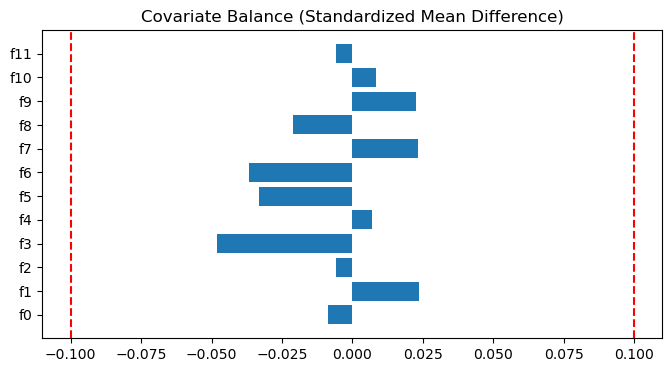

,feature,SMD
0,f0,-0.008845
1,f1,0.023527
2,f2,-0.005674
3,f3,-0.048073
4,f4,0.006848
5,f5,-0.033095
6,f6,-0.036880
7,f7,0.023259
8,f8,-0.021113
9,f9,0.022717


In [7]:
#1.2 Covariate balance
features = [f"f{i}" for i in range(12)]
rows = []
for f in features:
    t = df.loc[df.treatment == 1, f]
    c = df.loc[df.treatment == 0, f]
    smd = (t.mean() - c.mean()) / np.sqrt((t.var() + c.var()) / 2)
    rows.append((f, smd))
balance = pd.DataFrame(rows, columns=["feature", "SMD"])

plt.figure(figsize=(8, 4))
plt.barh(balance["feature"], balance["SMD"])
plt.axvline(0.1, color="red", linestyle="--"); plt.axvline(-0.1, color="red", linestyle="--")
plt.title("Covariate Balance (Standardized Mean Difference)")
plt.show()
balance

All 12 features have |SMD| < 0.1, the standard threshold for balance.
The largest imbalance is f3 (-0.048), followed by f6 (-0.037) and f5 (-0.033), all well within the limit.
This means treatment and control users look similar before the campaign, so any difference in outcomes can be attributed to the treatment.

In [8]:
#1.3 Exposure check
df.groupby("treatment")["exposure"].mean()

treatment
0    0.000000
1    0.036069
Name: exposure, dtype: float64

Exposure Check: No control users were exposed (0%), confirming no contamination. However, only 3.6% of treatment users were actually exposed to the ad. Therefore, the estimated effect is an intent-to-treat (ITT) effect, which is diluted relative to the true effect on exposed users. The effect on exposed users (CACE) can be approximated as ITT ÷ exposure rate.

Step 2: Estimate the effect

In [9]:
#2.1 Summary by group
summary = (df.groupby("treatment")
             .agg(n=("conversion", "size"),
                  conversions=("conversion", "sum"),
                  visits=("visit", "sum"),
                  conv_rate=("conversion", "mean"),
                  visit_rate=("visit", "mean")))
summary

,n,conversions,visits,conv_rate,visit_rate
treatment,,,,,
0,209711,407,7961,0.001941,0.037962
1,1188248,3683,57629,0.003100,0.048499


The campaign increased conversions by about 60% and visits by about 28% (intent-to-treat).
Conversions are rare (only 407 in control), so the confidence interval for conversion lift will be wider than for visits. Step 2.2 will confirm whether it's significant.
Given the 3.6% exposure rate, the effect on users who actually saw the ad (CACE) is much larger: roughly +3.2 pp in conversion (0.00116 ÷ 0.036). Mention this carefully, since it assumes the campaign only works through actual exposure.

In [10]:
#2.2 Z-test, confidence interval, and lift (reusable function)
def ab_test(success_col):
    x_t, n_t = summary.loc[1, success_col], summary.loc[1, "n"]
    x_c, n_c = summary.loc[0, success_col], summary.loc[0, "n"]
    z, p = proportions_ztest([x_t, x_c], [n_t, n_c])
    p_t, p_c = x_t / n_t, x_c / n_c
    lo, hi = confint_proportions_2indep(x_t, n_t, x_c, n_c, method="wald")
    print(f"--- {success_col} ---")
    print(f"Control: {p_c:.5f} | Treatment: {p_t:.5f}")
    print(f"Absolute diff: {p_t - p_c:.5f} | Relative lift: {(p_t - p_c)/p_c:.2%}")
    print(f"95% CI (abs diff): [{lo:.5f}, {hi:.5f}] | p-value: {p:.2e}\n")
    return p_t, p_c, n_t, n_c

conv_res = ab_test("conversions")
visit_res = ab_test("visits")

--- conversions ---
Control: 0.00194 | Treatment: 0.00310
Absolute diff: 0.00116 | Relative lift: 59.71%
95% CI (abs diff): [0.00095, 0.00137] | p-value: 1.33e-19

--- visits ---
Control: 0.03796 | Treatment: 0.04850
Absolute diff: 0.01054 | Relative lift: 27.76%
95% CI (abs diff): [0.00963, 0.01144] | p-value: 2.92e-98



Effect Estimation: The campaign produced a statistically significant increase in conversion rate from 0.194% to 0.310% (+59.7% relative lift; 95% CI for absolute difference: 0.095 to 0.137 pp; p < 0.001) and in visit rate from 3.80% to 4.85% (+27.8%; 95% CI: 0.96 to 1.14 pp; p < 0.001). Given the large sample, the confidence intervals are more informative than p-values: even the lower bound shows a meaningful lift.

Conversion lift 95% bootstrap CI: [0.4477 0.7746]


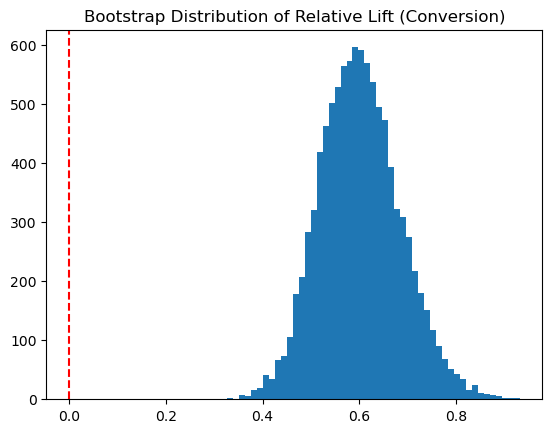

In [11]:
#2.3 Bootstrap CI for relative lift
def bootstrap_lift(p_t, p_c, n_t, n_c, B=10000, seed=42):
    rng = np.random.default_rng(seed)
    bt = rng.binomial(n_t, p_t, B) / n_t
    bc = rng.binomial(n_c, p_c, B) / n_c
    lift = (bt - bc) / bc
    return np.percentile(lift, [2.5, 97.5]), lift

ci_conv, lift_conv = bootstrap_lift(*conv_res)
print("Conversion lift 95% bootstrap CI:", np.round(ci_conv, 4))

plt.hist(lift_conv, bins=50)
plt.axvline(0, color="red", linestyle="--")
plt.title("Bootstrap Distribution of Relative Lift (Conversion)")
plt.show()

Relative conversion lift: +59.7%, 95% bootstrap CI: +44.8% to +77.5%
The whole distribution sits far to the right of 0 (the red line), so there's virtually no chance the true effect is zero or negative.
The CI is fairly wide (about 33 points) because control conversions are rare (only 407). The estimate is certain in direction, less precise in size.
The distribution is slightly right-skewed, which is expected for a ratio (lift divides by the control rate). That's why the bootstrap is a better choice than a simple symmetric CI for relative lift, a good point for interviews.

In [12]:
ci_visit, lift_visit = bootstrap_lift(*visit_res)
print("Visit lift 95% bootstrap CI:", np.round(ci_visit, 4))

Visit lift 95% bootstrap CI: [0.2488 0.3074]


Relative visit lift: +27.8%, 95% bootstrap CI: +24.9% to +30.7%
This interval is much narrower (about 6 points) than the conversion interval (about 33 points), because visits are far more common than conversions (7,961 vs. 407 in control). More events mean more precise estimates.
Both metrics agree in direction: the campaign clearly drives more visits and more conversions.

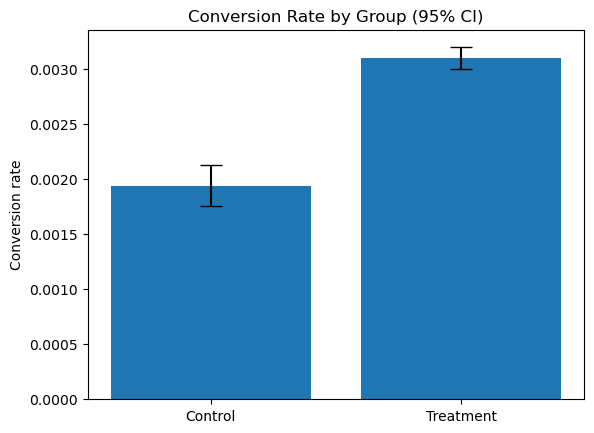

In [13]:
#2.4 Chart: conversion rate with 95% CI
rates = summary["conv_rate"]
errs = 1.96 * np.sqrt(rates * (1 - rates) / summary["n"])
plt.bar(["Control", "Treatment"], rates, yerr=errs, capsize=8)
plt.ylabel("Conversion rate"); plt.title("Conversion Rate by Group (95% CI)")
plt.show()

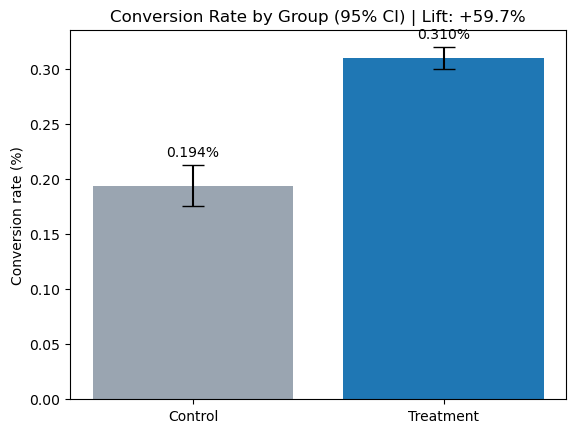

In [14]:
rates_pct = summary["conv_rate"] * 100
errs_pct = errs * 100
bars = plt.bar(["Control", "Treatment"], rates_pct, yerr=errs_pct, capsize=8, color=["#9aa5b1", "#1f77b4"])
for bar, r, e in zip(bars, rates_pct, errs_pct):
    plt.text(bar.get_x() + bar.get_width()/2, r + e + 0.008, f"{r:.3f}%", ha="center")
plt.ylabel("Conversion rate (%)")
plt.title("Conversion Rate by Group (95% CI) | Lift: +59.7%")
plt.show()

# Step 3: Power Analysis

In [15]:
#Setup values
p_t, p_c, n_t, n_c = conv_res
alpha, power = 0.05, 0.80
ratio = n_t / n_c
print(f"Baseline conversion: {p_c:.5f} | Control n: {n_c:,} | Treatment n: {n_t:,} | Ratio: {ratio:.2f}")

Baseline conversion: 0.00194 | Control n: 209,711 | Treatment n: 1,188,248 | Ratio: 5.67


Baseline conversion (control): 0.194%, a very low base rate, which makes conversion effects harder to detect.
Ratio: 5.67, meaning there are about 5.67 treated users for every control user (the 85/15 split).
The control group (210K) is the limiting factor for precision. Even with 1.19M treated users, the small control group sets how small an effect you can reliably detect.

In [16]:
#Minimum Detectable Effect (MDE)
z_a, z_b = norm.ppf(1 - alpha/2), norm.ppf(power)
mde_abs = (z_a + z_b) * np.sqrt(p_c * (1 - p_c) * (1/n_t + 1/n_c))
mde_rel = mde_abs / p_c
print(f"MDE absolute: {mde_abs:.5f} ({mde_abs*100:.3f} pp)")
print(f"MDE relative: {mde_rel:.2%}")
print(f"Observed lift: {(p_t - p_c)/p_c:.2%} -> {'above' if (p_t-p_c) > mde_abs else 'below'} MDE")

MDE absolute: 0.00029 (0.029 pp)
MDE relative: 15.05%
Observed lift: 59.71% -> above MDE


Minimum Detectable Effect: With 209,711 control and 1,188,248 treatment users, the experiment had 80% power to detect a relative conversion lift of 15.05% (0.029 pp) at α = 0.05. The observed lift of 59.7% is roughly four times the MDE, confirming the experiment was adequately powered. However, smaller effects (below ~15%) would not have been reliably detectable with this design.

In [17]:
#Sample size needed for different target lifts
targets = [0.05, 0.10, 0.20, 0.30]
rows = []
for lift in targets:
    es = proportion_effectsize(p_c * (1 + lift), p_c)
    n_c_needed = NormalIndPower().solve_power(effect_size=abs(es), alpha=alpha, power=power, ratio=ratio)
    rows.append((f"{lift:.0%}", round(n_c_needed), round(n_c_needed * ratio), round(n_c_needed * (1 + ratio))))
sample_table = pd.DataFrame(rows, columns=["Target lift", "Control needed", "Treatment needed", "Total needed"])
sample_table

,Target lift,Control needed,Treatment needed,Total needed
0,5%,1946594,11029636,12976230
1,10%,498285,2823345,3321630
2,20%,130295,738265,868560
3,30%,60402,342244,402645


Sample size grows roughly with the square of how small the effect is. Halving the target lift (10% → 5%) needs about 4 times more users (3.3M → 13M).
Your 10% sample (1.4M) can reliably detect lifts of about 15% or more, which matches the MDE.
The full Criteo dataset (~14M users) would be just enough to detect a 5% lift. That's a good reason to mention for why large-scale data matters.
In business terms: small, realistic improvements need very large experiments, especially when the baseline conversion rate is low (0.19%).

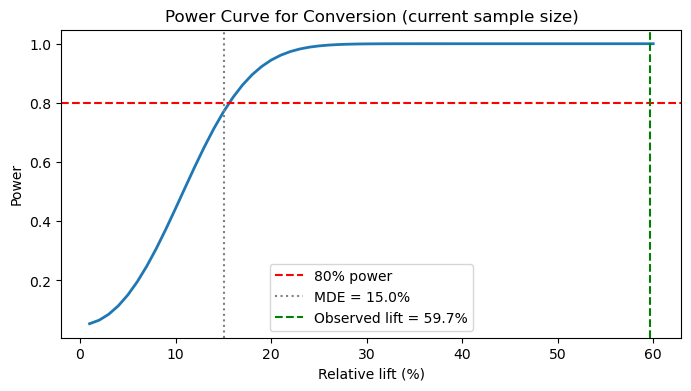

In [18]:
#Power curve
lifts = np.linspace(0.01, 0.60, 60)
powers = [NormalIndPower().power(effect_size=abs(proportion_effectsize(p_c*(1+l), p_c)),
                                 nobs1=n_c, alpha=alpha, ratio=ratio) for l in lifts]

plt.figure(figsize=(8, 4))
plt.plot(lifts * 100, powers, linewidth=2)
plt.axhline(0.8, color="red", linestyle="--", label="80% power")
plt.axvline(mde_rel * 100, color="gray", linestyle=":", label=f"MDE = {mde_rel:.1%}")
plt.axvline((p_t - p_c)/p_c * 100, color="green", linestyle="--", label=f"Observed lift = {(p_t-p_c)/p_c:.1%}")
plt.xlabel("Relative lift (%)"); plt.ylabel("Power")
plt.title("Power Curve for Conversion (current sample size)")
plt.legend(); plt.show()

The curve crosses 80% power at about 15% lift, exactly matching the MDE. Your calculations are consistent.
The observed lift (59.7%) sits where power is essentially 100%, so the experiment was certain to detect an effect of that size.
For smaller effects, power drops quickly: roughly 45% at a 10% lift and under 20% at a 5% lift. A real but small effect would often be missed.

In [19]:
#What if the split were 50/50? 
n_total = n_t + n_c
n_half = n_total / 2
mde_5050 = (z_a + z_b) * np.sqrt(p_c * (1 - p_c) * (2 / n_half))
print(f"MDE with 85/15 split: {mde_rel:.2%}")
print(f"MDE with 50/50 split: {mde_5050/p_c:.2%}")

MDE with 85/15 split: 15.05%
MDE with 50/50 split: 10.75%


Allocation Trade-off: Holding total sample size constant, a 50/50 split would reduce the MDE from 15.05% to 10.75%, making the experiment about 29% more sensitive. The 85/15 design sacrifices statistical sensitivity in exchange for a smaller holdout group, limiting the business cost of withholding the campaign from customers. The choice of allocation should balance detection needs against the opportunity cost of the control group.

In [20]:
#ffect on exposed users (CACE)
exposure_rate = df.loc[df.treatment == 1, "exposure"].mean()
cace_conv = (p_t - p_c) / exposure_rate
p_tv, p_cv = visit_res[0], visit_res[1]
cace_visit = (p_tv - p_cv) / exposure_rate
print(f"Exposure rate: {exposure_rate:.2%}")
print(f"CACE conversion: +{cace_conv*100:.2f} pp | CACE visit: +{cace_visit*100:.2f} pp")

Exposure rate: 3.61%
CACE conversion: +3.21 pp | CACE visit: +29.21 pp


mportant caveats (mention these in your notebook and interviews):

It applies only to "compliers": users for whom Criteo won the ad auction. These may be more active or high-intent users, so the effect may not generalize to all users.
It assumes the exclusion restriction: that assignment affects outcomes only through exposure. If being in the treatment group influenced users in other ways, the estimate would be biased.
No confidence interval yet: dividing by a small exposure rate (3.6%) amplifies uncertainty. The true interval is much wider than for ITT. (You could bootstrap it later.)

Write this in a Markdown cell:

Effect on Exposed Users (CACE): Scaling the ITT effect by the 3.61% exposure rate (Wald estimator), the estimated effect among exposed users is +3.21 pp in conversion and +29.2 pp in visits. This indicates the campaign's impact is highly concentrated among users who actually saw the ad. However, this estimate applies only to compliers (users for whom the ad auction was won), relies on the exclusion restriction, and carries substantially greater uncertainty than the ITT estimate due to the low exposure rate. It should be treated as indicative rather than precise.

In [21]:
#Final Results Table
results = pd.DataFrame({
    "Metric": ["Conversion", "Visit"],
    "Control rate": [f"{p_c:.3%}", f"{p_cv:.3%}"],
    "Treatment rate": [f"{p_t:.3%}", f"{p_tv:.3%}"],
    "Relative lift": [f"{(p_t-p_c)/p_c:.1%}", f"{(p_tv-p_cv)/p_cv:.1%}"],
    "95% Bootstrap CI": [f"[{ci_conv[0]:.1%}, {ci_conv[1]:.1%}]", f"[{ci_visit[0]:.1%}, {ci_visit[1]:.1%}]"],
})
results

,Metric,Control rate,Treatment rate,Relative lift,95% Bootstrap CI
0,Conversion,0.194%,0.310%,59.7%,"[44.8%, 77.5%]"
1,Visit,3.796%,4.850%,27.8%,"[24.9%, 30.7%]"
